In [1]:
import sqlite3, time, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats as sp_stats
from pathlib import Path
warnings.filterwarnings('ignore')


# Perp-to-Bet Frontrunning: Per-Second Lead/Lag Analysis

How many seconds do Binance perpetual futures prices **lead** Polymarket bet prices in the
last 2 minutes before settlement?

**Method**: Using 500 randomly sampled markets from Section 8 (with millisecond-resolution
futures aggTrades), we build 1-second VWAP for perp prices and 1-second last-trade price
for Polymarket bets, both aligned to `[-120s, 0s]` relative to settlement.

Three complementary analyses:

1. **Cross-correlation** — correlate 1s perp price changes with 1s bet price changes at
   lags from -30s to +30s. A peak at positive lag means perp moves *first*.
   Also computed in 30-second windows to check if the lead is stable or varies near settlement.

2. **Impulse response** — when the perp price makes a large move (>75th percentile),
   how does the bet price evolve over the next 20 seconds? This shows the *absorption curve*:
   how fast Polymarket traders react to new price information from Binance.

3. **Per-second signal accuracy** — at each second `t` before settlement, use
   `sign(perp_cumulative_return(t))` to predict the market outcome. Track accuracy,
   Pearson correlation with outcome, and edge over the bet-implied probability.

In [2]:
# Build aligned 1-second matrices for the last 2 minutes before settlement.
# Self-contained: loads all required data from cached parquets + DB directly.
#
# Outputs used by the next two cells:
#   perp_px   (N, 120) — futures VWAP at each second in [-120s, -1s]
#   bet_px    (N, 120) — last Polymarket trade price at each second
#   perp_chg  (N, 119) — 1s perp price changes
#   bet_chg   (N, 119) — 1s bet price changes
#   perp_ret  (N, 120) — cumulative perp return from t=-120s (%)
#   valid_ll  (N,)     — mask: full 1s coverage for both perp and bet
#   valid_all (N,)     — mask: valid_ll AND has outcome
#   actual_up_ll (N,)  — binary outcome (1=up, 0=down)
#   ll_mids   (N,)     — market_id for each row

import sqlite3
from scipy import stats as sp_stats
from pathlib import Path

DB_PATH = '../backtest_data.db'
OUTPUT_DIR = Path('output')

# Load cached data
_granular = pd.read_parquet(OUTPUT_DIR / 'granular_trades.parquet')
_traj_df = pd.read_parquet(OUTPUT_DIR / 'bet_trajectories.parquet')
_mw = pd.read_parquet(OUTPUT_DIR / 'market_windows.parquet')
_conn = sqlite3.connect(DB_PATH)
_conn.execute('PRAGMA cache_size=-64000')

print(f'Loaded: {len(_granular):,} aggTrades for {_granular["market_id"].nunique()} markets, '
      f'{len(_traj_df):,} trajectories, {len(_mw):,} market windows')

# --- 1s Futures VWAP from aggTrades ---
fut_g = _granular[(_granular['source'] == 'futures') &
                   (_granular['offset_sec'].between(-120, -0.001))].copy()
fut_g['sec_bin'] = fut_g['offset_sec'].astype(int)
fut_g['dollar_vol'] = fut_g['price'] * fut_g['qty']

vw = fut_g.groupby(['market_id', 'sec_bin']).agg(
    dv=('dollar_vol', 'sum'), q=('qty', 'sum'))
vw['vwap'] = vw['dv'] / vw['q']
vw_piv = vw['vwap'].unstack(level='sec_bin')

sec_range = list(range(-120, 0))
for s in sec_range:
    if s not in vw_piv.columns:
        vw_piv[s] = np.nan
vw_piv = vw_piv[sec_range].sort_index()
perp_px = vw_piv.ffill(axis=1).bfill(axis=1).values
ll_mids = vw_piv.index.values

# --- 1s Bet prices from DB ---
meta_ll = pd.DataFrame({'market_id': ll_mids}).merge(
    _mw[['market_id', 'token_a', 'window_end_ts']], on='market_id')
n_mkts = len(meta_ll)
bet_px = np.full((n_mkts, 120), np.nan)

for bs in range(0, n_mkts, 200):
    batch = meta_ll.iloc[bs:bs + 200]
    tids = batch['token_a'].tolist()
    settles = batch['window_end_ts'].values.astype(int)
    ph = ','.join(['?'] * len(tids))
    tr = pd.read_sql_query(
        f'SELECT token_id, timestamp, CAST(price AS REAL) as price '
        f'FROM historical_trades WHERE token_id IN ({ph}) AND timestamp BETWEEN ? AND ? '
        f'ORDER BY token_id, timestamp',
        _conn, params=tids + [int(settles.min()) - 130, int(settles.max()) + 10])
    if len(tr) == 0:
        continue
    for j, (_, mk) in enumerate(batch.iterrows()):
        st = int(mk['window_end_ts'])
        t = tr[(tr['token_id'] == mk['token_a']) &
               (tr['timestamp'] >= st - 120) & (tr['timestamp'] <= st)]
        for off, p in zip(t['timestamp'].values - st, t['price'].values):
            si = int(off) + 120
            if 0 <= si < 120:
                bet_px[bs + j, si] = p

_conn.close()
bet_px = pd.DataFrame(bet_px).ffill(axis=1).bfill(axis=1).values

# --- Derived arrays ---
perp_chg = np.diff(perp_px, axis=1)   # (N, 119)
bet_chg = np.diff(bet_px, axis=1)     # (N, 119)
valid_ll = ~np.isnan(perp_chg).any(axis=1) & ~np.isnan(bet_chg).any(axis=1)

perp_ret = (perp_px - perp_px[:, 0:1]) / perp_px[:, 0:1] * 100

mid_to_out = dict(zip(_traj_df['market_id'], _traj_df['actual_outcome']))
actual_up_ll = np.array([1 if mid_to_out.get(m) == 'up' else
                         (0 if mid_to_out.get(m) == 'down' else np.nan)
                         for m in ll_mids])
valid_all = valid_ll & ~np.isnan(actual_up_ll)

# Cleanup temp refs
del _granular, _traj_df, _mw, _conn, fut_g, vw, vw_piv, meta_ll

print(f'1s matrices: {perp_px.shape[0]} markets, {perp_px.shape[1]} seconds')
print(f'Valid (full perp + bet + outcome): {valid_all.sum()}')

Loaded: 946,039 aggTrades for 500 markets, 11,592 trajectories, 11,696 market windows
1s matrices: 500 markets, 120 seconds
Valid (full perp + bet + outcome): 488


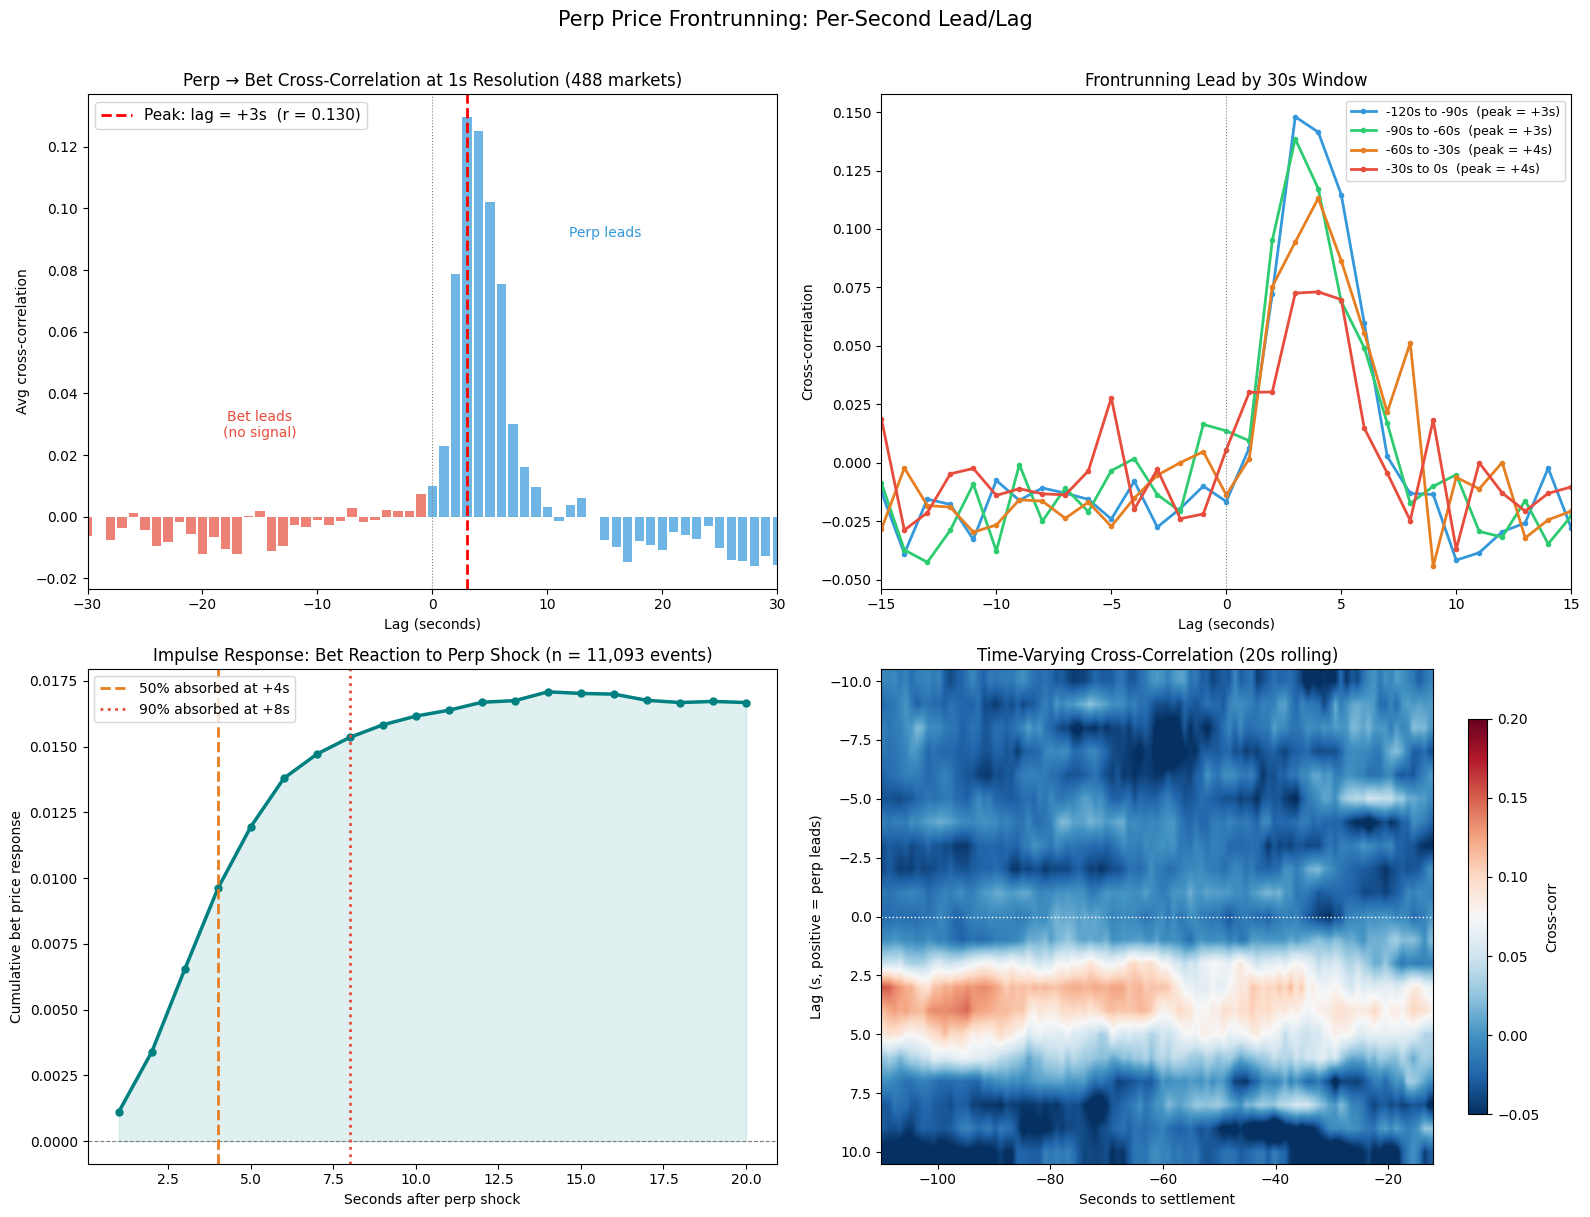


FRONTRUNNING LEAD/LAG SUMMARY
  Markets analyzed:       488
  Peak cross-corr lag:    +3s  (r = 0.1297)
  Lag=0 correlation:      0.0099

  Cross-correlation at key lags:
      Lag     Corr
      -5s  -0.0009
      -1s   0.0075
      +0s   0.0099
      +1s   0.0229
      +2s   0.0786
      +3s   0.1297
      +4s   0.1252
      +5s   0.1022
     +10s   0.0033

  Lead by window:
       -120s to -90s:  +3s  (r = 0.1480)
        -90s to -60s:  +3s  (r = 0.1385)
        -60s to -30s:  +4s  (r = 0.1131)
          -30s to 0s:  +4s  (r = 0.0731)

  Impulse response (11,093 events):
    50% absorbed in 4s
    90% absorbed in 8s
    Full response:  0.016675 bet-price units


In [3]:
# Cross-correlation & impulse response: how many seconds does perp lead bet?
#
# Panel 1: Cross-correlation at 1s lags [-30s, +30s].
#           Positive lag = perp change at t correlates with bet change at t+lag.
# Panel 2: Same cross-corr computed in 4 sliding 30s windows to see if the lead
#           is stable or changes as settlement approaches.
# Panel 3: Impulse response — after a top-quartile perp move, cumulative bet
#           price response over the next 20s. Shows the absorption curve:
#           how fast the bet market incorporates the information.
# Panel 4: Rolling-window heatmap of cross-corr (X = time to settlement,
#           Y = lag) showing the lead structure everywhere.

n_v = valid_ll.sum()
pv, bv = perp_chg[valid_ll], bet_chg[valid_ll]

# --- 1. Overall cross-correlation ---
MAX_LAG = 30
lags = np.arange(-MAX_LAG, MAX_LAG + 1)
xcorr = np.zeros(len(lags))
xcn = np.zeros(len(lags))

for i in range(n_v):
    p, b = pv[i], bv[i]
    sp, sb = p.std(), b.std()
    if sp == 0 or sb == 0:
        continue
    pn, bn = (p - p.mean()) / sp, (b - b.mean()) / sb
    for k, lag in enumerate(lags):
        if lag >= 0:
            ps, bs = (pn[:len(pn) - lag], bn[lag:]) if lag > 0 else (pn, bn)
        else:
            bs, ps = bn[:len(bn) + lag], pn[-lag:]
        if len(ps) >= 20:
            xcorr[k] += np.mean(ps * bs)
            xcn[k] += 1

xcorr_avg = np.where(xcn > 0, xcorr / xcn, 0)
peak_lag = lags[np.argmax(xcorr_avg)]
peak_corr = xcorr_avg.max()

# --- 2. Time-varying cross-corr (30s windows) ---
windows = [(-120, -90), (-90, -60), (-60, -30), (-30, 0)]
win_results = {}
for ws, we in windows:
    i0, i1 = ws + 120, we + 120 - 1
    wl = np.arange(-15, 16)
    wc = np.zeros(len(wl))
    wn = 0
    for mi in range(n_v):
        pw, bw = pv[mi, i0:i1 + 1], bv[mi, i0:i1 + 1]
        if pw.std() == 0 or bw.std() == 0:
            continue
        pn = (pw - pw.mean()) / pw.std()
        bn = (bw - bw.mean()) / bw.std()
        for k, lag in enumerate(wl):
            if lag >= 0:
                ps, bs = (pn[:len(pn) - lag], bn[lag:]) if lag > 0 else (pn, bn)
            else:
                bs, ps = bn[:len(bn) + lag], pn[-lag:]
            if len(ps) >= 5:
                wc[k] += np.mean(ps * bs)
        wn += 1
    if wn > 0:
        wc /= wn
    win_results[f'{ws}s to {we}s'] = (wl, wc)

# --- 3. Impulse response ---
impulse_h = 20
impulse_resp = np.zeros(impulse_h)
imp_n = 0

for mi in range(n_v):
    p, b = pv[mi], bv[mi]
    thresh = np.percentile(np.abs(p), 75)
    for t in range(30, 100):  # avoid edges
        if t + impulse_h >= len(p) or abs(p[t]) < thresh:
            continue
        impulse_resp += np.cumsum(b[t + 1:t + 1 + impulse_h]) * np.sign(p[t])
        imp_n += 1

if imp_n > 0:
    impulse_resp /= imp_n
total_resp = impulse_resp[-1]

# --- 4. Rolling heatmap ---
roll_w = 20
t_centers = np.arange(10, 109)
lag_range = np.arange(-10, 11)
heatmap = np.full((len(t_centers), len(lag_range)), np.nan)

for ti, tc in enumerate(t_centers):
    i0 = max(0, tc - roll_w // 2)
    i1 = min(pv.shape[1], tc + roll_w // 2)
    for k, lag in enumerate(lag_range):
        vals = []
        for mi in range(n_v):
            pw, bw = pv[mi, i0:i1], bv[mi, i0:i1]
            if pw.std() == 0 or bw.std() == 0:
                continue
            pn = (pw - pw.mean()) / pw.std()
            bn = (bw - bw.mean()) / bw.std()
            if lag >= 0:
                ps, bs = (pn[:len(pn) - lag], bn[lag:]) if lag > 0 else (pn, bn)
            else:
                bs, ps = bn[:len(bn) + lag], pn[-lag:]
            if len(ps) >= 5:
                vals.append(np.mean(ps * bs))
        if vals:
            heatmap[ti, k] = np.mean(vals)

# === PLOT ===
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Overall cross-correlation
ax = axes[0, 0]
colors_bar = ['#e74c3c' if l < 0 else '#3498db' for l in lags]
ax.bar(lags, xcorr_avg, width=0.8, color=colors_bar, alpha=0.7)
ax.axvline(peak_lag, color='red', ls='--', lw=2,
           label=f'Peak: lag = +{peak_lag}s  (r = {peak_corr:.3f})')
ax.axvline(0, color='gray', ls=':', lw=0.8)
ax.set_xlabel('Lag (seconds)')
ax.set_ylabel('Avg cross-correlation')
ax.set_title(f'Perp \u2192 Bet Cross-Correlation at 1s Resolution ({n_v} markets)')
ax.legend(fontsize=11, loc='upper left')
ax.set_xlim(-MAX_LAG, MAX_LAG)
ax.annotate('Perp leads', xy=(15, peak_corr * 0.7), fontsize=10, color='#3498db', ha='center')
ax.annotate('Bet leads\n(no signal)', xy=(-15, peak_corr * 0.2), fontsize=10,
            color='#e74c3c', ha='center')

# Panel 2: Time-varying lead
ax = axes[0, 1]
colors_w = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']
for idx_w, (label, (wl, wc)) in enumerate(win_results.items()):
    pk = wl[np.argmax(wc)]
    ax.plot(wl, wc, 'o-', color=colors_w[idx_w], lw=2, markersize=3,
            label=f'{label}  (peak = +{pk}s)')
ax.axvline(0, color='gray', ls=':', lw=0.8)
ax.set_xlabel('Lag (seconds)')
ax.set_ylabel('Cross-correlation')
ax.set_title('Frontrunning Lead by 30s Window')
ax.legend(fontsize=9)
ax.set_xlim(-15, 15)

# Panel 3: Impulse response
ax = axes[1, 0]
ax.plot(range(1, impulse_h + 1), impulse_resp, 'o-', color='teal', lw=2.5, markersize=5)
ax.fill_between(range(1, impulse_h + 1), 0, impulse_resp, alpha=0.12, color='teal')
ax.axhline(0, ls='--', color='gray', lw=0.8)
if total_resp > 0:
    for frac, clr, style in [(0.5, '#e67e22', '--'), (0.9, '#e74c3c', ':')]:
        idx_f = np.searchsorted(impulse_resp, total_resp * frac)
        if idx_f < impulse_h:
            ax.axvline(idx_f + 1, color=clr, ls=style, lw=2,
                       label=f'{int(frac*100)}% absorbed at +{idx_f+1}s')
ax.set_xlabel('Seconds after perp shock')
ax.set_ylabel('Cumulative bet price response')
ax.set_title(f'Impulse Response: Bet Reaction to Perp Shock (n = {imp_n:,} events)')
ax.legend(fontsize=10)

# Panel 4: Rolling heatmap
ax = axes[1, 1]
im = ax.imshow(heatmap.T, aspect='auto', cmap='RdBu_r',
               extent=[-120 + t_centers[0], -120 + t_centers[-1],
                       lag_range[-1] + 0.5, lag_range[0] - 0.5],
               vmin=-0.05, vmax=0.20, interpolation='bilinear')
ax.set_xlabel('Seconds to settlement')
ax.set_ylabel('Lag (s, positive = perp leads)')
ax.set_title('Time-Varying Cross-Correlation (20s rolling)')
ax.axhline(0, color='white', ls=':', lw=1)
plt.colorbar(im, ax=ax, shrink=0.8, label='Cross-corr')

plt.suptitle('Perp Price Frontrunning: Per-Second Lead/Lag', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# --- Numeric summary ---
print(f'\n{"="*60}')
print(f'FRONTRUNNING LEAD/LAG SUMMARY')
print(f'{"="*60}')
print(f'  Markets analyzed:       {n_v}')
print(f'  Peak cross-corr lag:    +{peak_lag}s  (r = {peak_corr:.4f})')
print(f'  Lag=0 correlation:      {xcorr_avg[MAX_LAG]:.4f}')
print()
print(f'  Cross-correlation at key lags:')
print(f'    {"Lag":>5} {"Corr":>8}')
for l in [-5, -1, 0, 1, 2, 3, 4, 5, 10]:
    print(f'    {l:>+4}s {xcorr_avg[l + MAX_LAG]:>8.4f}')
print()
print(f'  Lead by window:')
for label, (wl, wc) in win_results.items():
    pk = wl[np.argmax(wc)]
    print(f'    {label:>16s}:  +{pk}s  (r = {wc.max():.4f})')
print()
if total_resp > 0:
    abs50 = np.searchsorted(impulse_resp, total_resp * 0.5) + 1
    abs90 = np.searchsorted(impulse_resp, total_resp * 0.9) + 1
    print(f'  Impulse response ({imp_n:,} events):')
    print(f'    50% absorbed in {abs50}s')
    print(f'    90% absorbed in {abs90}s')
    print(f'    Full response:  {total_resp:.6f} bet-price units')

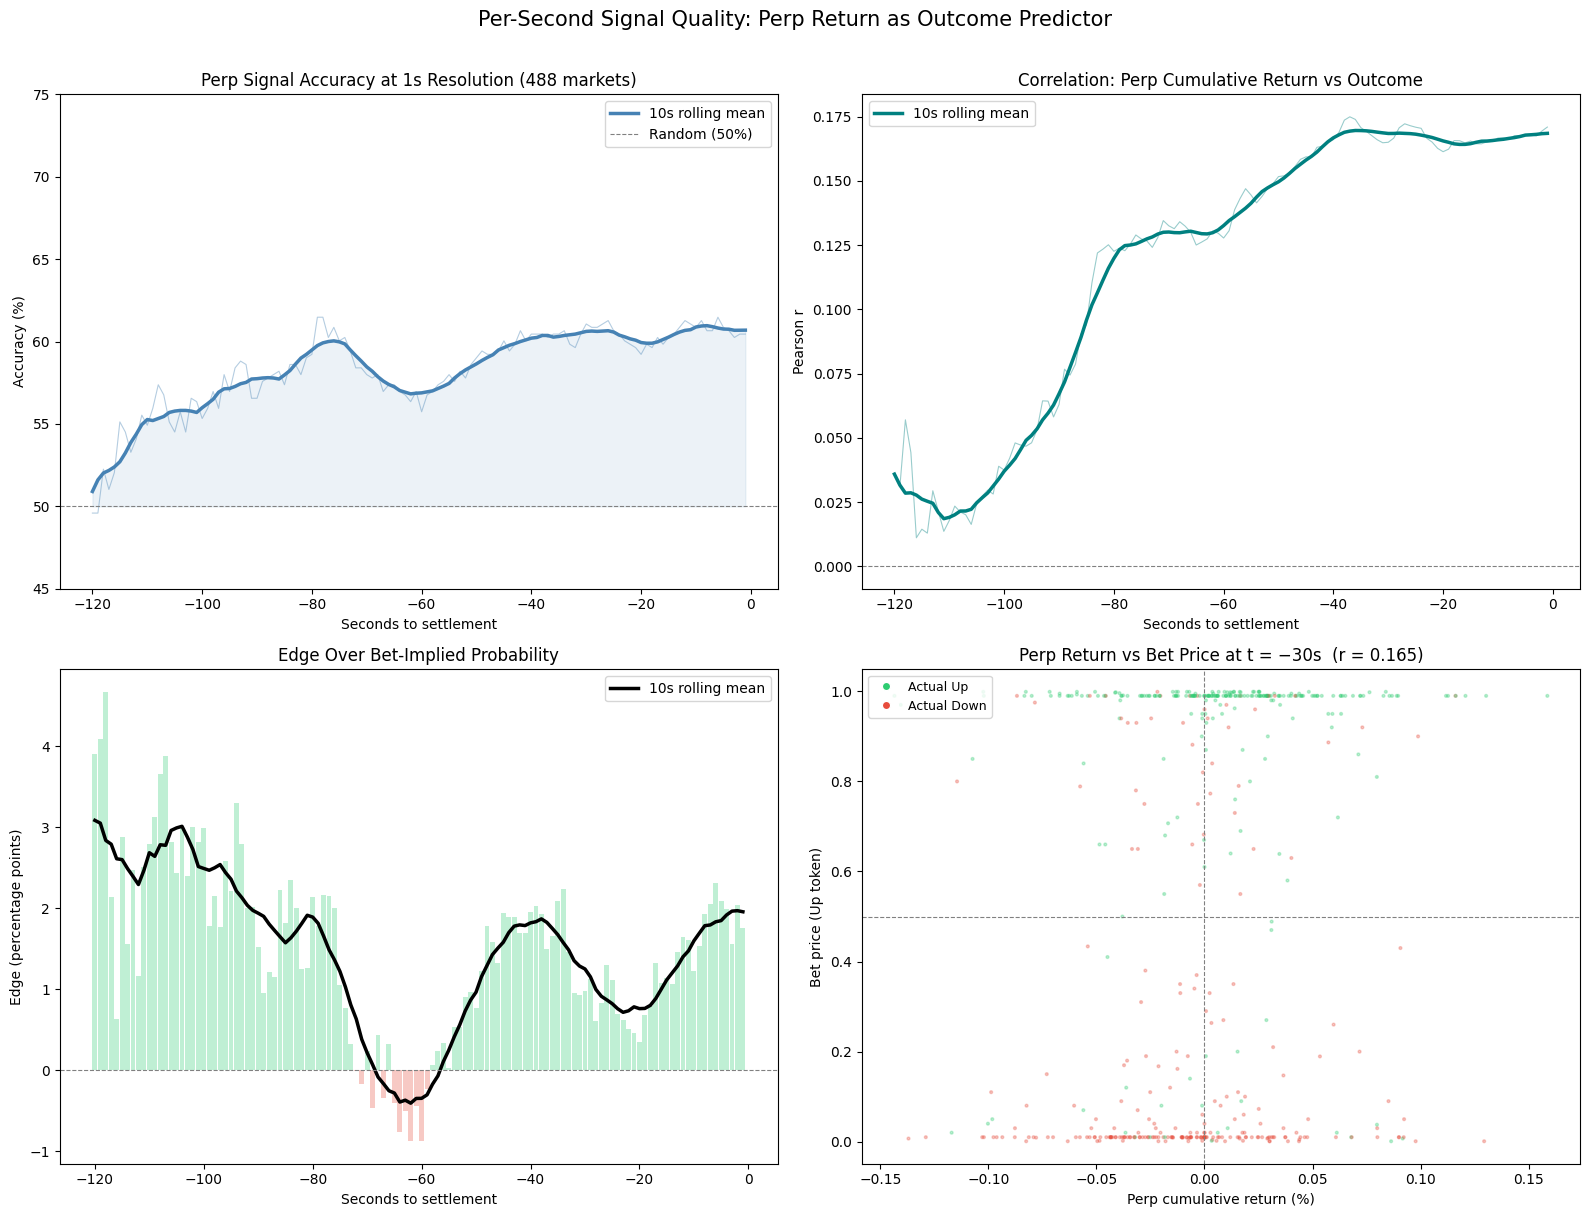


Signal accuracy at key times:
  t=-120s:  acc=49.6%  r=nan  edge=+3.9pp
  t= -90s:  acc=56.6%  r=0.063  edge=+1.5pp
  t= -60s:  acc=55.7%  r=0.128  edge=-0.9pp
  t= -30s:  acc=61.1%  r=0.165  edge=+1.0pp
  t= -10s:  acc=60.9%  r=0.167  edge=+1.2pp
  t=  -5s:  acc=60.9%  r=0.168  edge=+2.1pp
  t=  -1s:  acc=60.5%  r=0.171  edge=+1.8pp

  Avg edge t=[-120,-60]s: +1.74pp
  Avg edge t=[-60, 0]s:  +1.21pp


In [4]:
# Per-second signal accuracy & edge over the bet market
#
# At each second t in [-120s, -1s], the signal is sign(perp_cumulative_return(t)):
#   perp_ret > 0 → predict "up",  perp_ret < 0 → predict "down"
#
# Panel 1: Accuracy — fraction of markets where the signal matches the actual outcome.
#          Shows how fast the perp becomes informative.
# Panel 2: Pearson r between perp cumulative return and binary outcome (0/1).
#          Complements accuracy with a continuous measure of association.
# Panel 3: Edge = accuracy - bet_implied_prob.  The bet_implied_prob is what the
#          Polymarket price already implies for the predicted side, so edge > 0 means
#          the perp signal knows more than the bet market has priced in.
# Panel 4: Scatter at t=-30s: perp return vs bet price, colored by outcome.

secs = np.array(sec_range)
n_secs = len(secs)
pr_v = perp_ret[valid_all]
bp_v = bet_px[valid_all]
au_v = actual_up_ll[valid_all]

acc_1s = np.full(n_secs, np.nan)
r_1s = np.full(n_secs, np.nan)
edge_1s = np.full(n_secs, np.nan)

for i in range(n_secs):
    pi = pr_v[:, i]
    bi = bp_v[:, i]
    mi = ~np.isnan(pi) & ~np.isnan(bi)
    if mi.sum() < 50:
        continue
    p, b, a = pi[mi], bi[mi], au_v[mi]
    pred = p > 0
    acc_1s[i] = (pred == a.astype(bool)).mean()
    if np.std(p) > 0:
        r_1s[i], _ = sp_stats.pearsonr(p, a)
    edge_1s[i] = acc_1s[i] - np.where(pred, b, 1 - b).mean()

# Smoothed (10s rolling)
acc_sm = pd.Series(acc_1s * 100).rolling(10, center=True, min_periods=3).mean().values
r_sm = pd.Series(r_1s).rolling(10, center=True, min_periods=3).mean().values
edge_sm = pd.Series(edge_1s * 100).rolling(10, center=True, min_periods=3).mean().values

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Accuracy
ax = axes[0, 0]
ax.plot(secs, acc_1s * 100, lw=0.8, color='steelblue', alpha=0.4)
ax.plot(secs, acc_sm, lw=2.5, color='steelblue', label='10s rolling mean')
ax.axhline(50, ls='--', color='gray', lw=0.8, label='Random (50%)')
ax.fill_between(secs, 50, acc_sm, alpha=0.1, color='steelblue',
                where=~np.isnan(acc_sm))
ax.set_xlabel('Seconds to settlement')
ax.set_ylabel('Accuracy (%)')
ax.set_title(f'Perp Signal Accuracy at 1s Resolution ({valid_all.sum()} markets)')
ax.legend(fontsize=10)
ax.set_ylim(45, 75)

# Panel 2: Pearson r
ax = axes[0, 1]
ax.plot(secs, r_1s, lw=0.8, color='teal', alpha=0.4)
ax.plot(secs, r_sm, lw=2.5, color='teal', label='10s rolling mean')
ax.axhline(0, ls='--', color='gray', lw=0.8)
ax.set_xlabel('Seconds to settlement')
ax.set_ylabel('Pearson r')
ax.set_title('Correlation: Perp Cumulative Return vs Outcome')
ax.legend(fontsize=10)

# Panel 3: Edge
ax = axes[1, 0]
ax.bar(secs, edge_1s * 100, width=0.9, alpha=0.3,
       color=['#2ecc71' if e >= 0 else '#e74c3c' for e in edge_1s])
ax.plot(secs, edge_sm, lw=2.5, color='black', label='10s rolling mean')
ax.axhline(0, ls='--', color='gray', lw=0.8)
ax.set_xlabel('Seconds to settlement')
ax.set_ylabel('Edge (percentage points)')
ax.set_title('Edge Over Bet-Implied Probability')
ax.legend(fontsize=10)

# Panel 4: Scatter at t=-30s
ax = axes[1, 1]
t30 = 90  # index for -30s
pi30 = pr_v[:, t30]
bi30 = bp_v[:, t30]
mi30 = ~np.isnan(pi30) & ~np.isnan(bi30)
colors_sc = np.where(au_v[mi30] == 1, '#2ecc71', '#e74c3c')
ax.scatter(pi30[mi30], bi30[mi30], c=colors_sc, s=4, alpha=0.3, rasterized=True)
ax.axhline(0.5, ls='--', color='gray', lw=0.8)
ax.axvline(0, ls='--', color='gray', lw=0.8)
r30 = r_1s[t30]
ax.set_title(f'Perp Return vs Bet Price at t = \u221230s  (r = {r30:.3f})')
ax.set_xlabel('Perp cumulative return (%)')
ax.set_ylabel('Bet price (Up token)')
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=6, label='Actual Up'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=6, label='Actual Down'),
], fontsize=9, loc='upper left')

plt.suptitle('Per-Second Signal Quality: Perp Return as Outcome Predictor', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# --- Summary ---
print(f'\nSignal accuracy at key times:')
for t in [-120, -90, -60, -30, -10, -5, -1]:
    i = t + 120
    if i < n_secs and not np.isnan(acc_1s[i]):
        print(f'  t={t:>4d}s:  acc={acc_1s[i]*100:.1f}%  r={r_1s[i]:.3f}  edge={edge_1s[i]*100:+.1f}pp')

# Edge regime summary
early_edge = np.nanmean(edge_1s[:60]) * 100
late_edge = np.nanmean(edge_1s[60:]) * 100
print(f'\n  Avg edge t=[-120,-60]s: {early_edge:+.2f}pp')
print(f'  Avg edge t=[-60, 0]s:  {late_edge:+.2f}pp')